# Windrose: Storm Speed and IKE by Direction of Motion

6-panel polar bar chart, one per basin: bar height is average storm translation
speed in each of 32 directional bins (compass heading of motion), color is average
total IKE in that bin.

## Paths

See the repo README ("Setting IBTRACS_PATH / IKE_OUTPUT_DIR")
for why these are set here rather than relying on a shell-level `export`.

In [1]:
import os
os.environ["IBTRACS_PATH"] = "/home/sydney.e.walters/IBTrACS"
os.environ["IKE_OUTPUT_DIR"] = "/home/sydney.e.walters/IBTrACS_Manuscript_Figures"


## Imports

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm

from ike_climatology import config
from ike_climatology.ibtracs_io import load_master_dataframe
from ike_climatology.wind_asymmetry import BASIN_ABBREV_MAP


## Data extraction

In [3]:
master_df = load_master_dataframe(
    basins=config.BASINS_TO_ANALYZE,
    file_map=config.IBTRACS_FILE_MAP,
    basin_codes=config.IBTRACS_BASIN_CODES,
    start_year=config.START_YEAR,
    end_year=config.END_YEAR,
    land_interaction_threshold_km=config.LAND_INTERACTION_THRESHOLD_KM,
)

if master_df.empty:
    raise RuntimeError("No processable storm data found -- check IBTRACS_PATH.")


--- Starting Initial Data Loading and Processing for All Basins ---
    - Loading IBTrACS data for North Atlantic (2004-2024)
        Found 380 storms in file.
        - Filtered out 2 crossover/external storms based on official genesis basin label.
    - Loading IBTrACS data for East Pacific (2004-2024)
        Found 497 storms in file.
        - Filtered out 79 crossover/external storms based on official genesis basin label.
    - Loading IBTrACS data for West Pacific (2004-2024)
        Found 622 storms in file.
        - Filtered out 16 crossover/external storms based on official genesis basin label.
    - Loading IBTrACS data for North Indian (2004-2024)
        Found 220 storms in file.
        - Filtered out 13 crossover/external storms based on official genesis basin label.
    - Loading IBTrACS data for South Indian (2004-2024)
        Found 367 storms in file.
        - Filtered out 22 crossover/external storms based on official genesis basin label.
    - Loading IBTrACS data

## Bin storm speed and IKE by direction of motion

32 directional bins (0-360°, storm heading). Within each bin: average storm
translation speed (clipped to `MAX_STORM_SPEED`) and average total IKE, across
every qualifying timestep from every storm in that basin.

In [4]:
NUM_BINS = 32

bin_edges = np.linspace(0, 2 * np.pi, NUM_BINS + 1)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
bar_width = (2 * np.pi) / NUM_BINS

basin_ike_avg, basin_speed_avg = {}, {}

for full_basin_name, basin_group in master_df.groupby("basin"):
    abbrev = BASIN_ABBREV_MAP.get(full_basin_name)
    if not abbrev:
        continue

    theta = np.radians(basin_group["storm_dir_deg"].values) % (2 * np.pi)
    speed = np.clip(basin_group["stormspd_kts"].values)
    ike = basin_group["total_ike_tj"].values

    mask = ~np.isnan(theta) & ~np.isnan(speed) & ~np.isnan(ike)
    theta, speed, ike = theta[mask], speed[mask], ike[mask]

    bin_idx = np.clip(np.digitize(theta, bin_edges) - 1, 0, NUM_BINS - 1)

    ike_sum = np.bincount(bin_idx, weights=ike, minlength=NUM_BINS)
    speed_sum = np.bincount(bin_idx, weights=speed, minlength=NUM_BINS)
    count = np.bincount(bin_idx, minlength=NUM_BINS)

    with np.errstate(invalid="ignore", divide="ignore"):
        basin_ike_avg[abbrev] = np.divide(ike_sum, count, out=np.zeros(NUM_BINS), where=count > 0)
        basin_speed_avg[abbrev] = np.divide(speed_sum, count, out=np.zeros(NUM_BINS), where=count > 0)


## Figure: windrose (speed + IKE by direction)

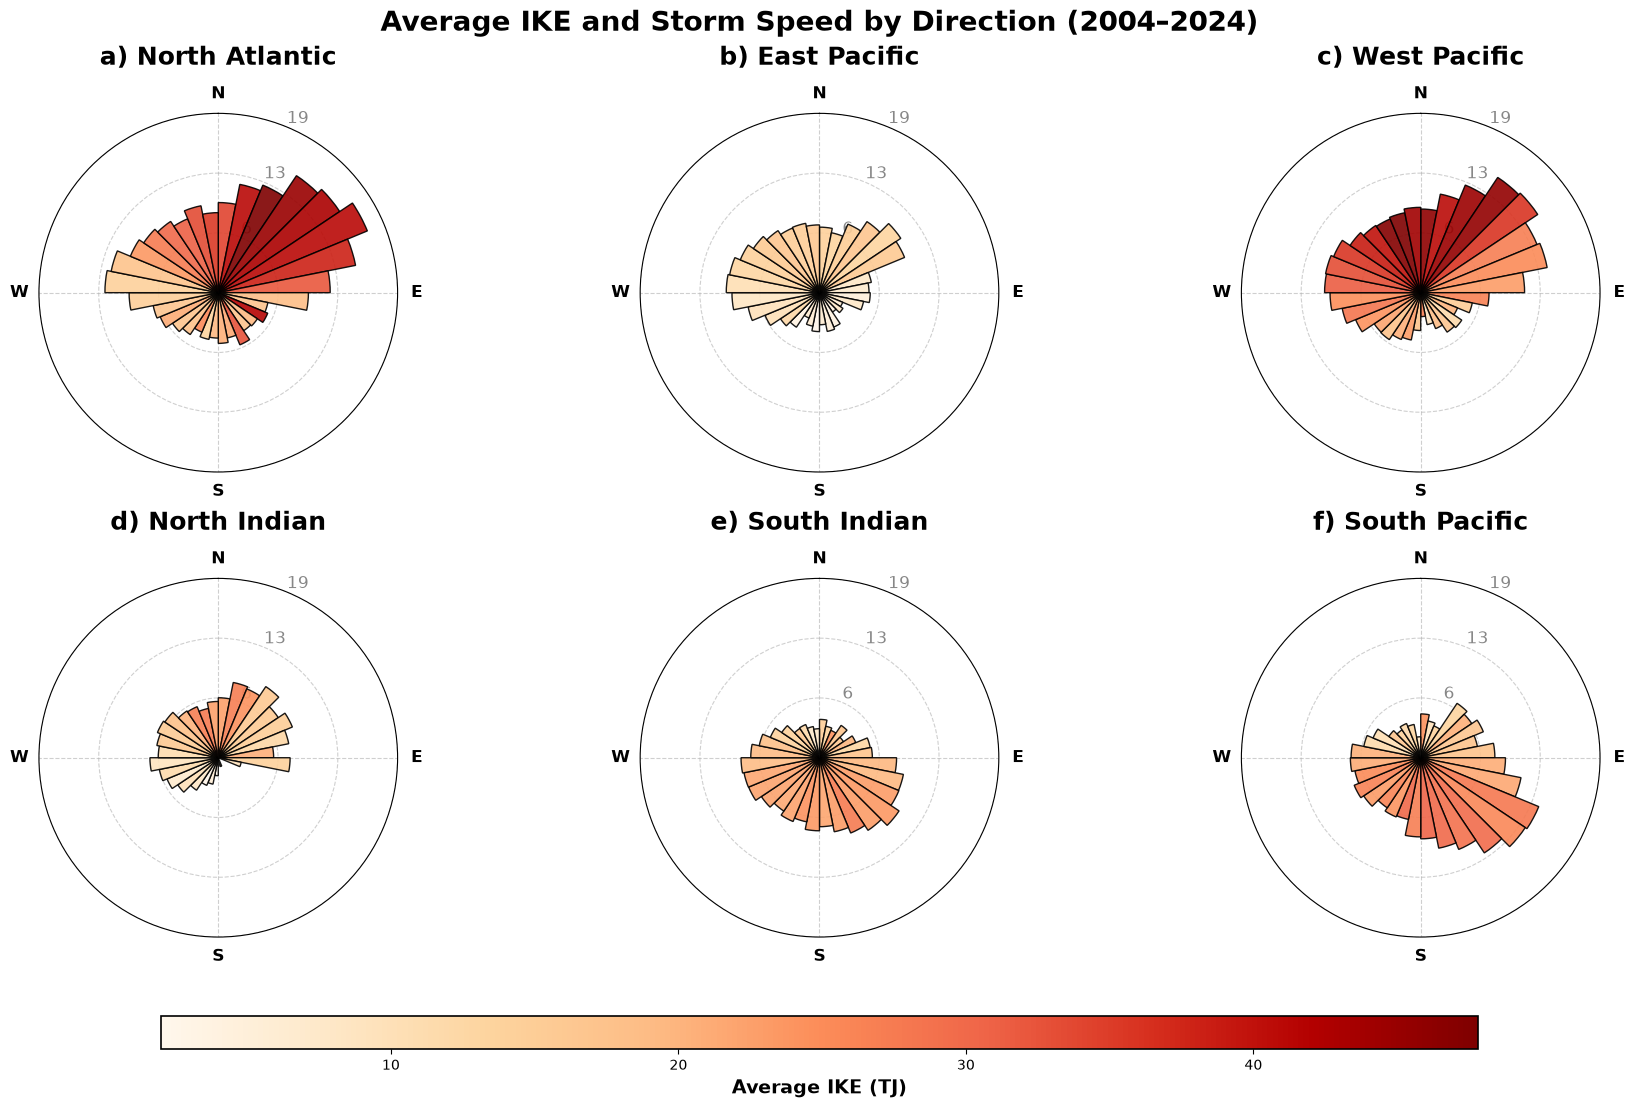

Plot saved to: /home/sydney.e.walters/IBTrACS_Manuscript_Figures/windrose_motion.png


In [5]:
custom_cmap = plt.get_cmap("OrRd")
all_avg_ike = np.concatenate(list(basin_ike_avg.values())) if basin_ike_avg else np.array([0, 1])
valid_ike = all_avg_ike[all_avg_ike > 0]
if len(valid_ike) == 0:
    valid_ike = np.array([0, 1])
norm = mcolors.Normalize(vmin=np.min(valid_ike), vmax=np.max(valid_ike))
all_speeds = [np.max(speed) for speed in basin_speed_avg.values() if len(speed) > 0]
global_max_speed = (max(all_speeds) + 2) if all_speeds else 30
labels = ["a)", "b)", "c)", "d)", "e)", "f)"]
fig, axes = plt.subplots(2, 3, subplot_kw={"projection": "polar"}, figsize=(18, 11), constrained_layout=True)
axes = axes.flatten()
for i, basin in enumerate(config.BASINS_TO_ANALYZE):
    ax = axes[i]
    abbrev = config.IBTRACS_BASIN_CODES[basin]
    if abbrev not in basin_ike_avg:
        ax.set_title(f"{basin}\n(No Data)", fontsize=18, fontweight="bold", pad=15)
        ax.set_xticks([]); ax.set_yticks([]); continue
    ike_avg = basin_ike_avg[abbrev]
    speed_avg = basin_speed_avg[abbrev]
    colors = [custom_cmap(norm(v)) for v in ike_avg]
    ax.bar(bin_centers, speed_avg, width=bar_width, color=colors, edgecolor="black", alpha=0.9, zorder=2)
    ax.set_title(f"{labels[i]} {basin}", fontsize=18, fontweight="bold", pad=15)
    ax.set_theta_zero_location("N")
    ax.set_theta_direction(-1)
    ax.set_xticks(np.radians([0, 90, 180, 270]))
    ax.set_xticklabels(["N", "E", "S", "W"], fontsize=12, fontweight="bold")
    ax.set_ylim(0, global_max_speed)
    ax.set_yticks(np.linspace(0, global_max_speed, 4))
    ax.set_yticklabels([f"{int(t)}" for t in np.linspace(0, global_max_speed, 4)],
                       color="dimgrey", size=12, alpha=0.8)
    ax.grid(True, linestyle="--", alpha=0.6, zorder=0)
sm = cm.ScalarMappable(cmap=custom_cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes.tolist(), orientation="horizontal", fraction=0.04, pad=0.06, aspect=40)
cbar.set_label("Average IKE (TJ)", fontsize=14, fontweight="bold")
cbar.outline.set_linewidth(1.2)
fig.suptitle(f"Average IKE and Storm Speed by Direction ({config.START_YEAR}\u2013{config.END_YEAR})",
             fontsize=20, fontweight="bold")
os.makedirs(config.BASE_OUTPUT_DIR, exist_ok=True)
save_path = os.path.join(config.BASE_OUTPUT_DIR, "windrose_motion.png")
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"Plot saved to: {save_path}")